In [1]:
import random
import time
import numpy as np
from tqdm import tqdm, trange
from alive_progress import alive_bar, alive_it
import matplotlib.pyplot as plt
import gc

In [2]:
class RSA:
    """
    RSA implementation for encryption, signature and station-to-station key exchange.
    """

    def __init__(self, private_key: int = None, public_key: int = None, n: int = None, fast_exp: callable = None) -> None:
        self.private_key = private_key
        self.public_key = public_key
        self.n = n
        self.challenge = "Bravo ! Je suis épousplouffé par ta maîtrise du timing attack sur RSA !"
        self.fast_exp = fast_exp if fast_exp is not None else self._default_fast_exp
    
    def copy(self):
        return RSA(self.private_key, self.public_key, self.n, self.fast_exp)

    def _default_fast_exp(self, y: int, x: int, n: int) -> int:
        """Apply fast exponentiation for y^x modulo n"""
        s = 1
        y %= n

        while x > 0:
            if (x % 2) == 1:
                s = (s * y) % n
            y = (y * y) % n
            x = x >> 1

        return s

    def setKeys(self, private_key: int, public_key: int, n: int) -> None:
        self.private_key = private_key
        self.public_key = public_key
        self.n = n

    def getKeys(self) -> list:
        return [self.public_key, self.n], [self.private_key, self.n]
    
    def exportPublicKey(self) -> list:
        return [self.public_key, self.n]

    def createKeyPair(self, size: int) -> list:
        p = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        q = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        n, e, d = self.key_generator(p, q, size=size)
        self.setKeys(d, e, n)
        return [n, e, d]

    def encrypt(self, message: int) -> int:
        return self.fast_exp(message, self.public_key, self.n)

    def decrypt(self, cipher: int, private_key: int = None) -> int:
        if private_key is not None:
            return self.fast_exp(cipher, private_key, self.n)
        return self.fast_exp(cipher, self.private_key, self.n)
    
    def createChallenge(self) -> int:
        challenge_int = int.from_bytes(self.challenge.encode(), 'big')
        self.challenge = self.encrypt(challenge_int)
        return self.challenge
    
    def decryptChallenge(self, tested_key: int) -> str:
        decrypted_challenge_int = self.decrypt(self.challenge, private_key=tested_key)
        decrypted_challenge_bytes = decrypted_challenge_int.to_bytes((decrypted_challenge_int.bit_length() + 7) // 8, 'big')
        return decrypted_challenge_bytes.decode()

    def fermat_test(self, n: int) -> bool:
        """
        Check if a number is primary by running Fermat test.
        """
        for _ in range(20):
            alpha = random.randint(2, n - 1)
            if self.fast_exp(alpha, n - 1, n) != 1:
                return False
        return True

    def primary_nb_generator(self, a: int, b: int, safe_prime: bool = False) -> int:
        """
        Generate primary number in range a, b

        Parameters
        ----------
        a : int
            lower bound
        b : int
            upper bound
        safe_prime : bool
            Generate primary number p with (p - 1) / 2 also primary

        Returns
        -------
        int
            Primary number generated

        """
        while True:
            p = random.randint(a, b)
            if self.fermat_test(p):
                if safe_prime:
                    if self.fermat_test((p - 1) / 2):
                        return p
                else:
                    return p

    def Euclide(self, a: int, b: int) -> list:
        """
        Euclide's extended algorithm, used to find decryption exponent d for RSA
        Return a list [pgcd(a, b), inverse of a mod b, inverse of b mod a]

        """
        if b > a:
            a, b = b, a  # swap

        r_0, r_1 = a, b
        s_0, s_1 = 1, 0
        t_0, t_1 = 0, 1

        while r_1 != 0:
            q = r_0 // r_1
            r_0, r_1 = r_1, r_0 - q * r_1
            s_0, s_1 = s_1, s_0 - q * s_1
            t_0, t_1 = t_1, t_0 - q * t_1

        return [r_0, s_0 % b, t_0 % a]

    def key_generator(self, p: int = 0, q: int = 0, e: int = 0, size: int = 512) -> list:
        """
        Generate public and private key for RSA
        """
        if p == 0:
            p = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))
        if q == 0:
            q = self.primary_nb_generator(2**(size//2 - 1), 2**(size//2))

        assert self.fermat_test(p), "p is not primary"
        assert self.fermat_test(q), "q is not primary"
        n = p * q
        phi_n = (p - 1) * (q - 1)

        if e != 0:
            pgcd, _, d = self.Euclide(phi_n, e)
            assert pgcd == 1, "pgcd(phi_n, e) is not equal to 1, so no private key found !"

        else:
            # Find a primary number e with phi_n
            while True:
                e = random.randint(2**(size - 1), 2**(size))
                pgcd, _, d = self.Euclide(phi_n, e)

                # If primary number with phi_n, claim public key
                if pgcd == 1:
                    break
        return n, e, d

In [3]:
#----------------------------------------------------------------------------
# Examples values
#----------------------------------------------------------------------------

# for RSA encryption :

p_A = 13109499994810966779468866046493465498469807493634236479294124421385342920350717814807375283698575766763256101470694189234369358996750113963585617491399169
q_A = 9497561827984502554523100157901534504433126034087863778629488755692649311435921364240405549590851856701860175924335776598684751639633322074428628372725777
n_A = p_A * q_A
e_A = 4574830074548708213
m_1 = 123456789132456789

# Expected results :
# 1) Check if p and q are indeed prime, then compute d_A and the ciphertext.
# 2) Expected values for d_A and the ciphertext (d_A is also used for station-to-station later)
d_A = 1685394382767324790326942621450485552187209875614438478305225564629345944620726038114923060947436330701451901921041511234432041036987266468290187679773130363479895993621867708066144608084390089775045890165825736468637468786667820591136139480545376198614216373031208691260339805721685482401743494212035728605
# cipher = 32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746
# 3) And show the decryption indeed finds the correct message m_1.

print("\n=============== RSA ENCRYPTION ===============\n")

RSA_instance = RSA()
n, e, d = RSA_instance.key_generator(p_A, q_A, e_A)
RSA_instance.setKeys(d, e, n)
assert d == d_A, "Private key generated is different from the expected key !"

print(f"Message:                {m_1}\n")

cipher = RSA_instance.encrypt(m_1)
assert cipher == 32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746, "Encrypted message is not correct !"
print(f"Ciphertext:             {cipher}\n")

recovered_message = RSA_instance.decrypt(cipher)
assert recovered_message == m_1, "Recovered message is different from original message !"
print(f"Decrypted ciphertext:   {recovered_message}")


=============== RSA ENCRYPTION ===============

Message:                123456789132456789

Ciphertext:             32468932964181322647810913060097066975304467072050643211304428656476623133068329653886195740426516038144100129255895281039142864272296799126753030014464755203797098445143314298922512718785433009136404533290100525054356166805463645892708927694801117827432767298393815743170470207262077229267156532545837844746

Decrypted ciphertext:   123456789132456789


In [4]:
# def collect_samples(RSA_instance: RSA, num_samples: int = 1000, num_repetitions: int = 1, server: bool = True, private_key: int = None, progress_bar: bool = True) -> list:
#     """
#     Collect samples of decryption times for different cipher texts.

#     Parameters
#     ----------
#     RSA_instance : RSA
#         An instance of the RSA class.
#     num_samples : int
#         Number of samples to collect.
#     num_repetitions : int
#         Number of times to repeat each measurement.
#     server : bool
#         Whether to simulate the server side.
#     private_key : int
#         The private key to test (only used when server=False).

#     Returns
#     -------
#     list
#         A list of tuples containing (tested_cipher, decryption_time).
#     """
#     samples = []

#     for _ in tqdm(range(num_samples), desc="Collecting server samples" if server else "Collecting samples"):
#         # Generate a random cipher text to test
#         tested_cipher = random.randint(1, RSA_instance.n - 1)

#         decryption_times = []

#         # In case of server
#         if server:
#             for _ in range(num_repetitions):
#                 start_time = time.perf_counter_ns()
#                 RSA_instance.decrypt(tested_cipher)
#                 end_time = time.perf_counter_ns()
#                 decryption_times.append(end_time - start_time)
#             decryption_time = np.mean(decryption_times)

#         # In case of client
#         else:
#             assert private_key is not None, "Private key must be provided when server=False"
#             start_time = time.perf_counter_ns()
#             for _ in range(num_repetitions):
#                 RSA_instance.decrypt(tested_cipher, private_key=private_key)
#             end_time = time.perf_counter_ns()
#             decryption_time = end_time - start_time
#             decryption_time /= num_repetitions
        
#         samples.append([tested_cipher, decryption_time])

#     return np.array(samples)

In [5]:
def remove_outliers(samples, percentile=0.25):
    samples = np.asarray(samples)
    
    if percentile >= 1:
        percentile /= 100
    
    down = np.percentile(samples, percentile * 100)
    up = np.percentile(samples, (1 - percentile) * 100)
    
    return samples[(samples >= down) & (samples <= up)]

def collect_samples(
    RSA_instance: RSA,
    num_samples: int = 1000,
    num_repetitions: int = 10000,
    private_key: int = None,
    progress_bar: bool = True,
    disable_gc: bool = True,
    warmup_reps: int = 200,
) -> np.ndarray:
    """Collect timing samples for RSA decryption.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    num_samples : int
        The number of timing samples to collect.
    num_repetitions : int
        The number of times to repeat each decryption operation.
    private_key : int, optional
        The private key to use for decryption. If not provided, the instance's private key will be used.
    progress_bar : bool, default=True
        Whether to display a progress bar.
    disable_gc : bool, default=True
        Whether to disable garbage collection during timing measurements.
    warmup_reps : int, default=200
        The number of warm-up repetitions.

    Returns
    -------
    np.ndarray
        An array of timing samples.
    """

    key = private_key if private_key is not None else RSA_instance.private_key

    # Deactivate GC and collect garbage to minimize its impact on timing measurements
    if disable_gc:
        gc.disable()
        gc.collect()

    # Locate hot references
    decrypt_fn = RSA_instance.decrypt
    perf_ns    = time.perf_counter_ns
    n          = RSA_instance.n

    # Warm-up (stabilize branch predictor + CPU caches)
    for _ in range(warmup_reps):
        decrypt_fn(random.randint(1, n - 1), private_key=key)

    # Buffer pre-allocated (zero allocation in inner loop)
    timing_buf = np.empty(num_repetitions, dtype=np.int64)
    samples    = np.empty((num_samples, 2), dtype=np.float64)

    for i in tqdm(range(num_samples), disable=not progress_bar, leave=False):
        cipher = random.randint(1, n - 1)

        for j in range(num_repetitions):
            t0 = perf_ns()
            decrypt_fn(cipher, private_key=key)
            timing_buf[j] = perf_ns() - t0

        samples[i] = [cipher, remove_outliers(timing_buf).mean()]

    if disable_gc:
        gc.enable()
    return samples

In [9]:
def timing_attack(RSA_instance: RSA, num_samples: int = 1000, num_repetitions: int = 1, num_iterations: int = 10, num_known_bits: int = 5, buffer_size: int = 5, disable_gc: bool = True, progress_bar: bool = False) -> int:
    """
    Perform a timing attack on the RSA instance to recover the private key.

    Parameters
    ----------
    RSA_instance : RSA
        An instance of the RSA class.
    num_samples : int
        Number of samples to collect for the attack.
    num_repetitions : int
        Number of times to repeat each measurement.
    num_iterations : int
        Number of iterations to perform.
    num_known_bits : int
        Number of known bits of the private key.
    buffer_size : int
        The size of the buffer for the beam search.
    disable_gc : bool
        Whether to disable garbage collection during timing measurements.
    progress_bar : bool
        Whether to display a progress bar during sample collection.

    Returns
    -------
    int
        The recovered private key.
    """
    server_samples = collect_samples(RSA_instance, num_samples, num_repetitions, disable_gc=disable_gc, progress_bar=progress_bar)
    initial_key = RSA_instance.private_key & ((1 << num_known_bits) - 1)

    # buffer of candidate keys
    candidate_keys = np.full(buffer_size, initial_key)

    # variance associated with each key
    candidate_variances = np.full(buffer_size, np.inf)

    # historical data
    history_keys = np.zeros((num_iterations, buffer_size))
    history_variances = np.zeros((num_iterations, buffer_size))

    error_rate = 0

    for i in range(num_iterations):

        tested_keys = []
        tested_variances = []

        # We test 2 hypotheses for each key in the buffer
        for key in candidate_keys:

            key_h0 = key
            key_h1 = key | (1 << (num_known_bits + i))

            h0_samples = collect_samples(RSA_instance, num_samples, num_repetitions, private_key=key_h0, disable_gc=disable_gc, progress_bar=progress_bar)
            h0_variance = np.var(server_samples[:, 1] - h0_samples[:, 1])

            tested_keys.append(key_h0)
            tested_variances.append(h0_variance)

            h1_samples = collect_samples(RSA_instance, num_samples, num_repetitions, private_key=key_h1, disable_gc=disable_gc, progress_bar=progress_bar)
            h1_variance = np.var(server_samples[:, 1] - h1_samples[:, 1])

            tested_keys.append(key_h1)
            tested_variances.append(h1_variance)

        tested_keys = np.array(tested_keys)
        tested_variances = np.array(tested_variances)

        # We keep the best buffer_size hypotheses
        best_indices = np.argsort(tested_variances)[:buffer_size]

        candidate_keys = tested_keys[best_indices]
        candidate_variances = tested_variances[best_indices]

        # Update historical data
        history_keys[i] = candidate_keys
        history_variances[i] = candidate_variances

        # debug : best key in the buffer and its associated bit
        best_key = candidate_keys[0]
        bit_guessed = (best_key >> (num_known_bits + i)) & 1
        bit_private_key = (RSA_instance.private_key >> (num_known_bits + i)) & 1

        print(f"Iteration {i + 1}/{num_iterations}: bit guessed {bit_guessed} (h0 variance = {h0_variance}, h1 variance = {h1_variance}) {'✓ CORRECT' if bit_guessed == bit_private_key else '✗ WRONG'}")

    # Compute error rate for each candidate key in the buffer
    error_rate = []
    for key, variance in zip(candidate_keys, candidate_variances):
        guessed_key = (key >> num_known_bits) % (1 << num_iterations)
        real_key = (RSA_instance.private_key >> num_known_bits) % (1 << num_iterations)
        errors = (guessed_key ^ real_key).bit_count()
        error_rate.append(errors / num_iterations * 100)
        print("\n" + "-" * 30)
        print(f"Candidate key:  {key}")
        print(f"Variance:       {variance}")
        print(f"Error rate:     {error_rate[-1]:.2f}%")
        print("-" * 30)
    return candidate_keys, error_rate

In [11]:
keys, error_rate = timing_attack(RSA_instance, num_samples=100, num_repetitions=100, num_iterations=10, num_known_bits=5, buffer_size=3, disable_gc=True, progress_bar=True)
print(f"\nRecovered keys: {keys}")
print(f"Error rates: {error_rate}")

Iteration 1/10: bit guessed 0 (h0 variance = 15612833712.780834, h1 variance = 15590063851.32523) ✓ CORRECT


Iteration 2/10: bit guessed 1 (h0 variance = 15590665630.398289, h1 variance = 15595426569.053267) ✓ CORRECT


Iteration 3/10: bit guessed 0 (h0 variance = 15617647544.119627, h1 variance = 15600834124.47438) ✗ WRONG


Iteration 4/10: bit guessed 1 (h0 variance = 15572291622.894287, h1 variance = 15593598456.762945) ✗ WRONG


Iteration 5/10: bit guessed 0 (h0 variance = 15589772909.827065, h1 variance = 15602394027.102097) ✓ CORRECT


Iteration 6/10: bit guessed 1 (h0 variance = 15611260705.693972, h1 variance = 15576271850.95583) ✓ CORRECT


Iteration 7/10: bit guessed 0 (h0 variance = 15563141286.150293, h1 variance = 15644562670.982546) ✓ CORRECT


Iteration 8/10: bit guessed 0 (h0 variance = 15664199343.18321, h1 variance = 15571048484.082169) ✗ WRONG


Iteration 9/10: bit guessed 0 (h0 variance = 15609270126.09527, h1 variance = 15585646225.145918) ✓ CORRECT


Iteration 10/10: bit guessed 1 (h0 variance = 15609009697.624668, h1 variance = 15549347943.60076) ✓ CORRECT

------------------------------
Candidate key:  24637
Variance:       15549347943.60076
Error rate:     60.00%
------------------------------

------------------------------
Candidate key:  19517
Variance:       15553162629.857643
Error rate:     50.00%
------------------------------

------------------------------
Candidate key:  5181
Variance:       15555906329.229622
Error rate:     40.00%
------------------------------

Recovered keys: [24637 19517  5181]
Error rates: [60.0, 50.0, 40.0]


In [20]:
def get_samples_stats(
    RSA_instance: RSA,
    d_A: int,
    num_samples: int = 10000,
    disable_gc: bool = False,
    warmup_reps: int = 0,
    progress_bar: bool = True,
) -> np.ndarray:
    """
    Collect decryption times for a fixed ciphertext.

    Parameters
    ----------
    RSA_instance : RSA
    d_A : int
        Private key.
    num_samples : int
    disable_gc : bool
        Disable GC during measurement (default: False).
    warmup_reps : int
        Warm-up iterations before measurement (0 = no warm-up).
    progress_bar : bool
        Show progress bar during measurement (default: True).
    Returns
    -------
    np.ndarray  shape (num_samples,), times in nanoseconds.
    """
    if disable_gc:
        gc.disable()
        gc.collect()

    # Localize hot references
    decrypt_fn = RSA_instance.decrypt
    perf_ns    = time.perf_counter_ns

    # Warm-up
    for _ in tqdm(range(warmup_reps), desc="Warm-up", disable=not progress_bar, leave=False):
        decrypt_fn(d_A)

    # Pre-allocated buffer
    samples = np.empty(num_samples, dtype=np.int64)
    for i in tqdm(range(num_samples), desc="Sampling", disable=not progress_bar, leave=False):
        t0 = perf_ns()
        decrypt_fn(d_A)
        samples[i] = perf_ns() - t0

    if disable_gc:
        gc.enable()

    return samples


In [21]:
def plot_distributions(samples_stats_h0: np.ndarray, samples_stats_h1: np.ndarray, percentile=25, title: str = "Distribution of decryption times for two hypotheses with branch prediction"):
    plt.figure(figsize=(12, 8))
    plt.suptitle(title)
    plt.subplot(2, 2, 1)
    plt.hist(samples_stats_h0, bins=200)
    plt.axvline(np.mean(samples_stats_h0), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h0):.4f} ms')
    plt.title("Hypothesis h0: the last bit is 0")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.subplot(2, 2, 2)
    plt.hist(samples_stats_h1, bins=200)
    plt.axvline(np.mean(samples_stats_h1), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(samples_stats_h1):.4f} ms')
    plt.title("Hypothesis h1: the last bit is 1")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.subplot(2, 2, 3)
    plt.hist(remove_outliers(samples_stats_h0, percentile=percentile), bins=50)
    plt.axvline(np.mean(remove_outliers(samples_stats_h0, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h0, percentile=percentile)):.4f} ms')
    plt.title("Hypothesis h0: the last bit is 0 (without outliers)")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.subplot(2, 2, 4)
    plt.hist(remove_outliers(samples_stats_h1, percentile=percentile), bins=50)
    plt.axvline(np.mean(remove_outliers(samples_stats_h1, percentile=percentile)), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(remove_outliers(samples_stats_h1, percentile=percentile)):.4f} ms')
    plt.title("Hypothesis h1: the last bit is 1 (without outliers)")
    plt.xlabel("Decryption Time")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
small_key = d_A & ((1 << 16) - 1)
h0_small_key = small_key
h1_small_key = small_key | (1 << 16)

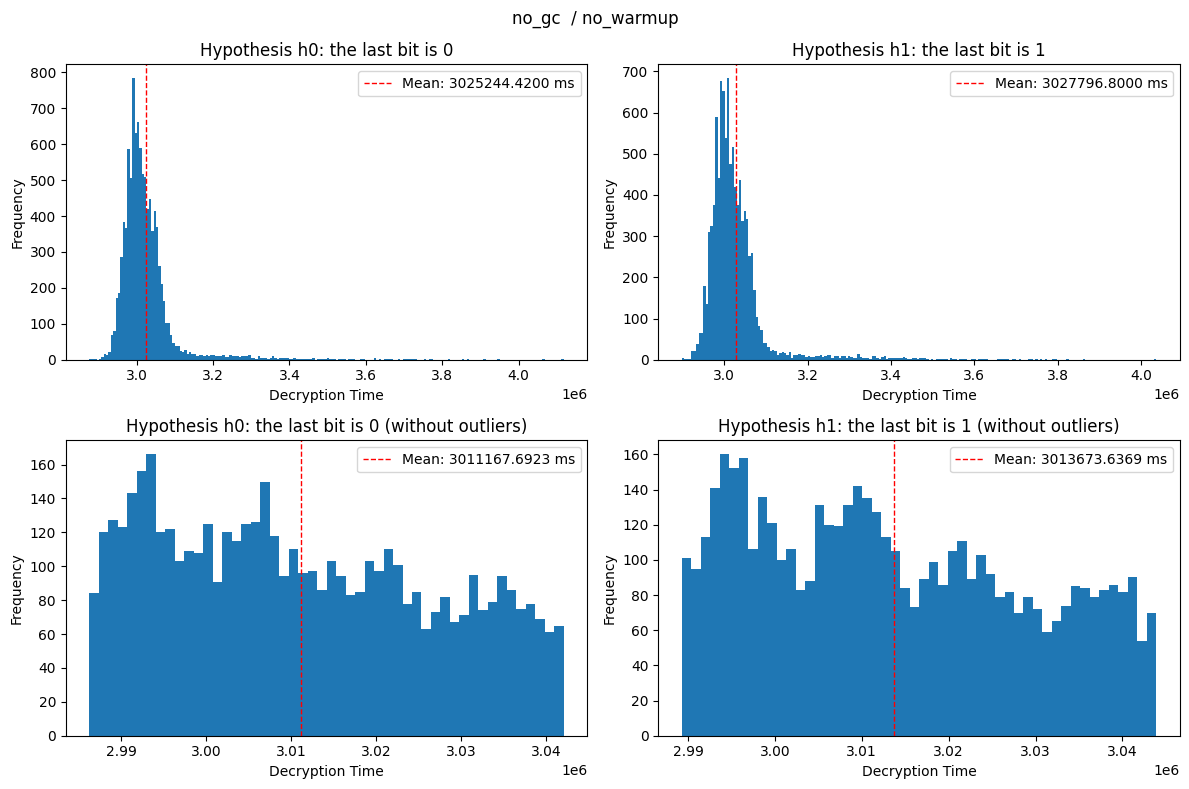

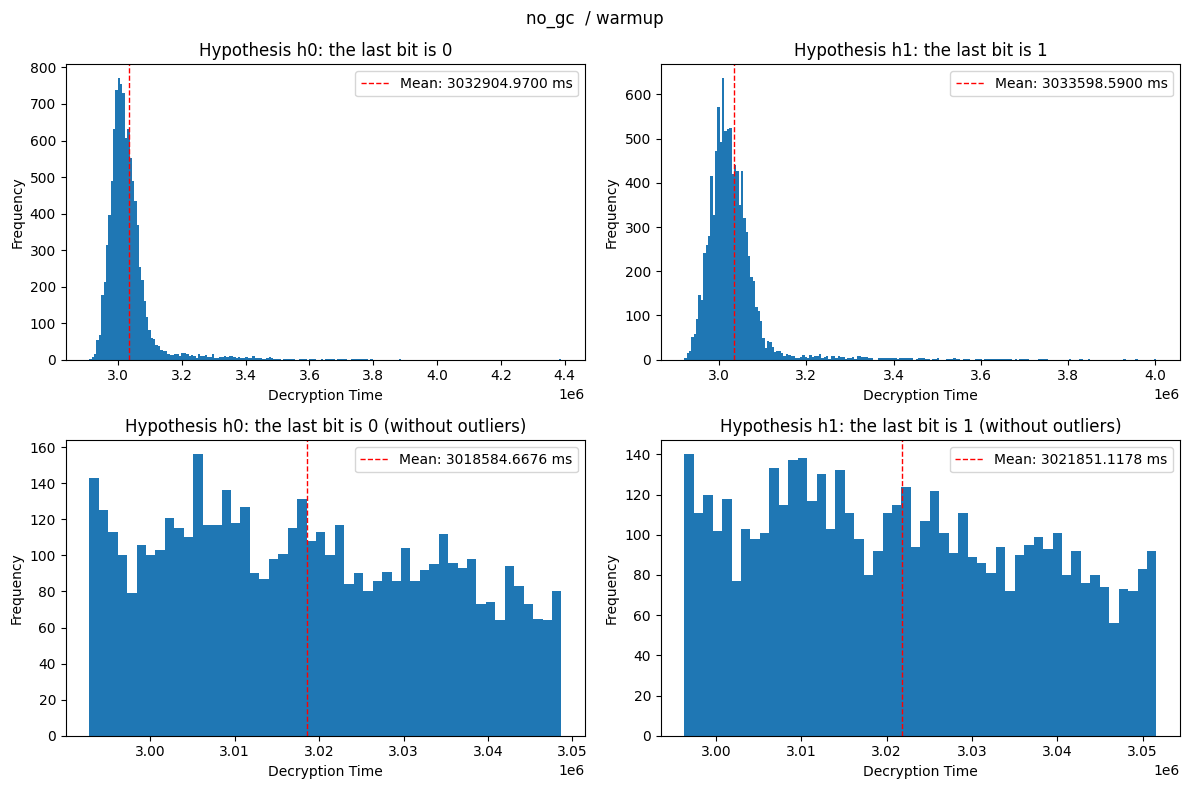

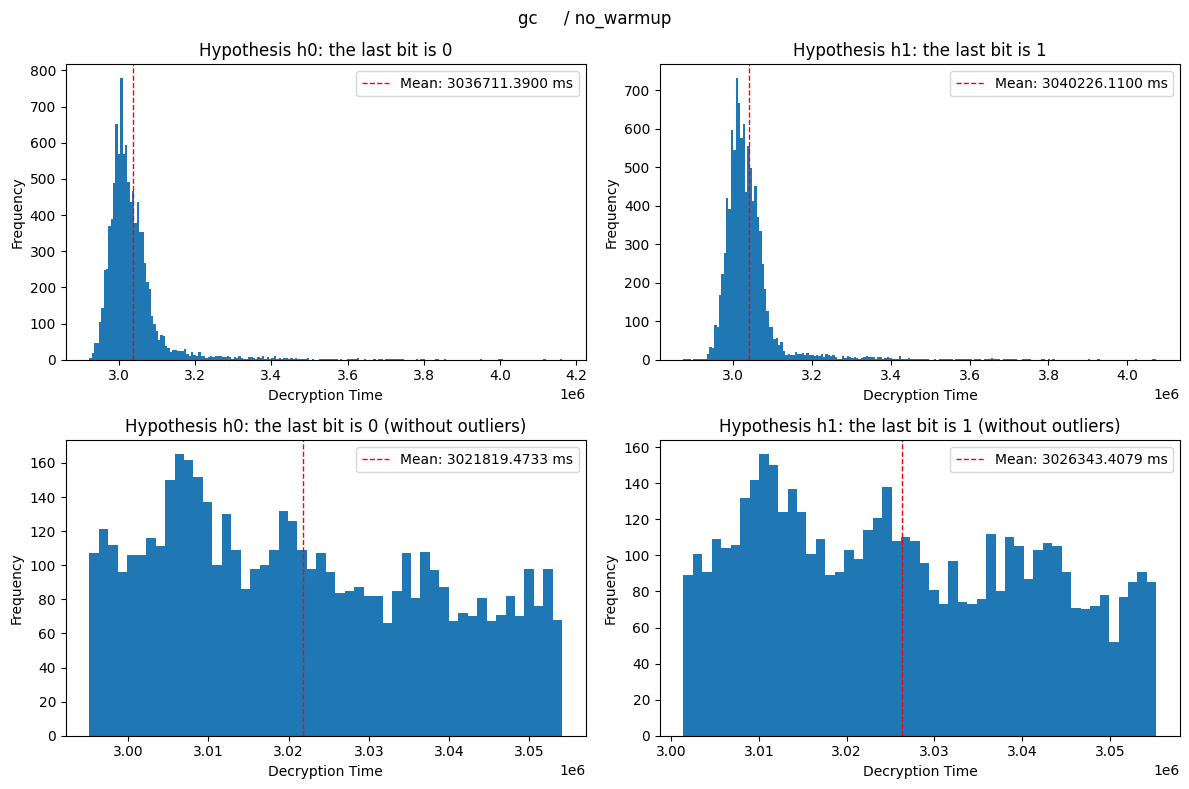

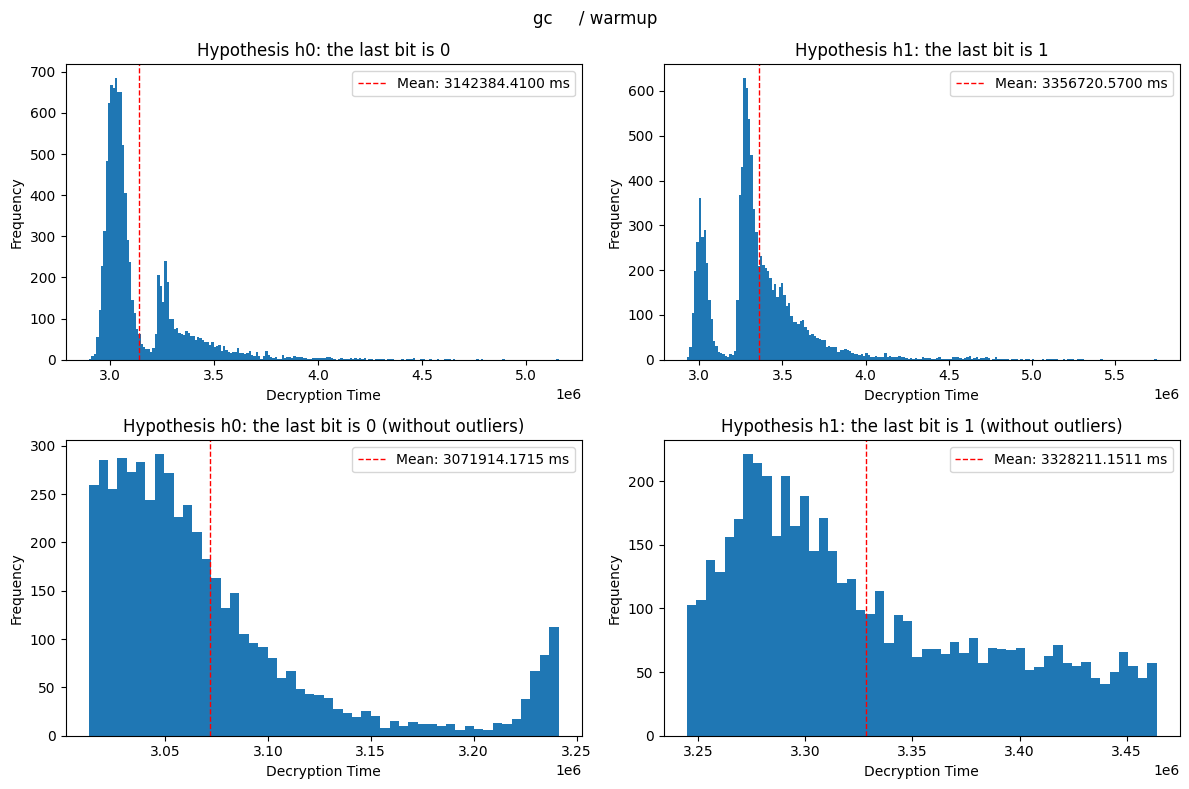

In [ ]:
configs = {
    "Garbage Collection / No Warm-up" : dict(disable_gc=False, warmup_reps=0),
    "Garbage Collection / Warm-up"    : dict(disable_gc=False, warmup_reps=200),
    "No Garbage Collection / No Warm-up" : dict(disable_gc=True, warmup_reps=0),
    "No Garbage Collection / Warm-up"    : dict(disable_gc=True, warmup_reps=200),
}

results = {
    label: (
        get_samples_stats(RSA_instance, h0_small_key, **cfg) / 1e6,
        get_samples_stats(RSA_instance, h1_small_key, **cfg) / 1e6,
    )
    for label, cfg in configs.items()
}

for label, (h0, h1) in results.items():
    plot_distributions(h0, h1, title=label)

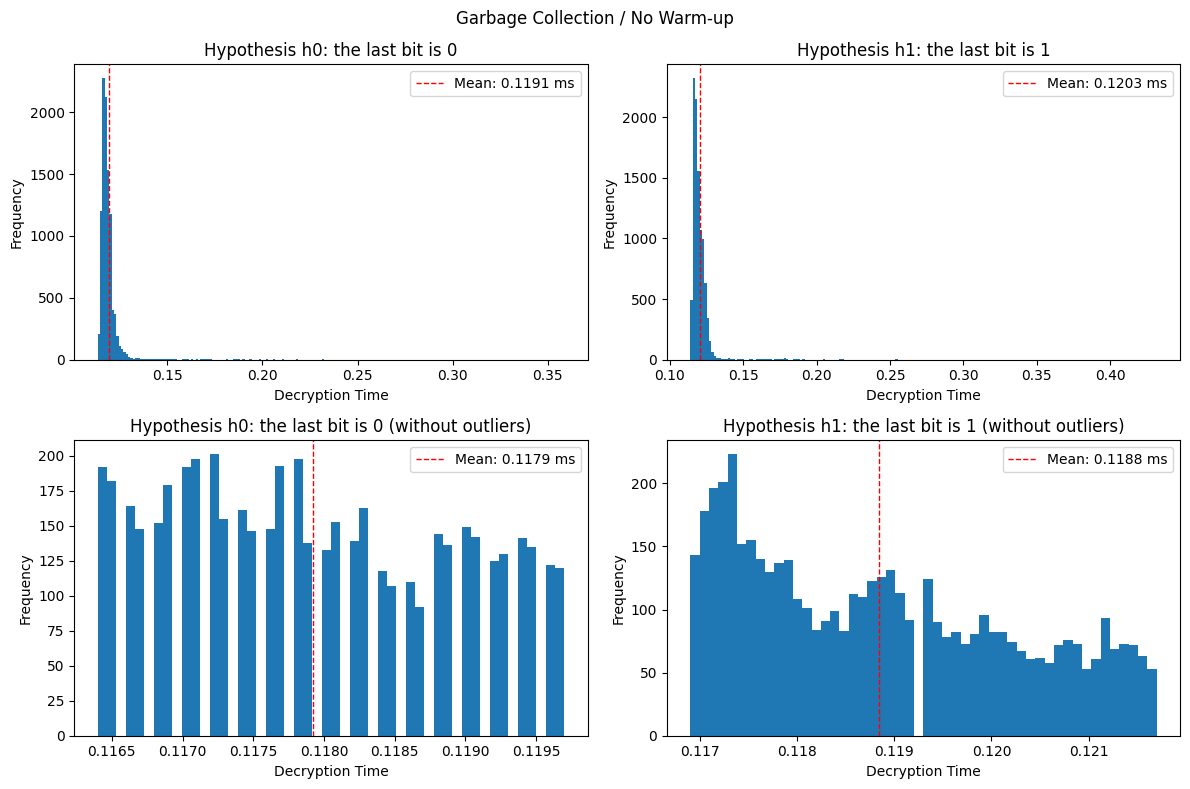

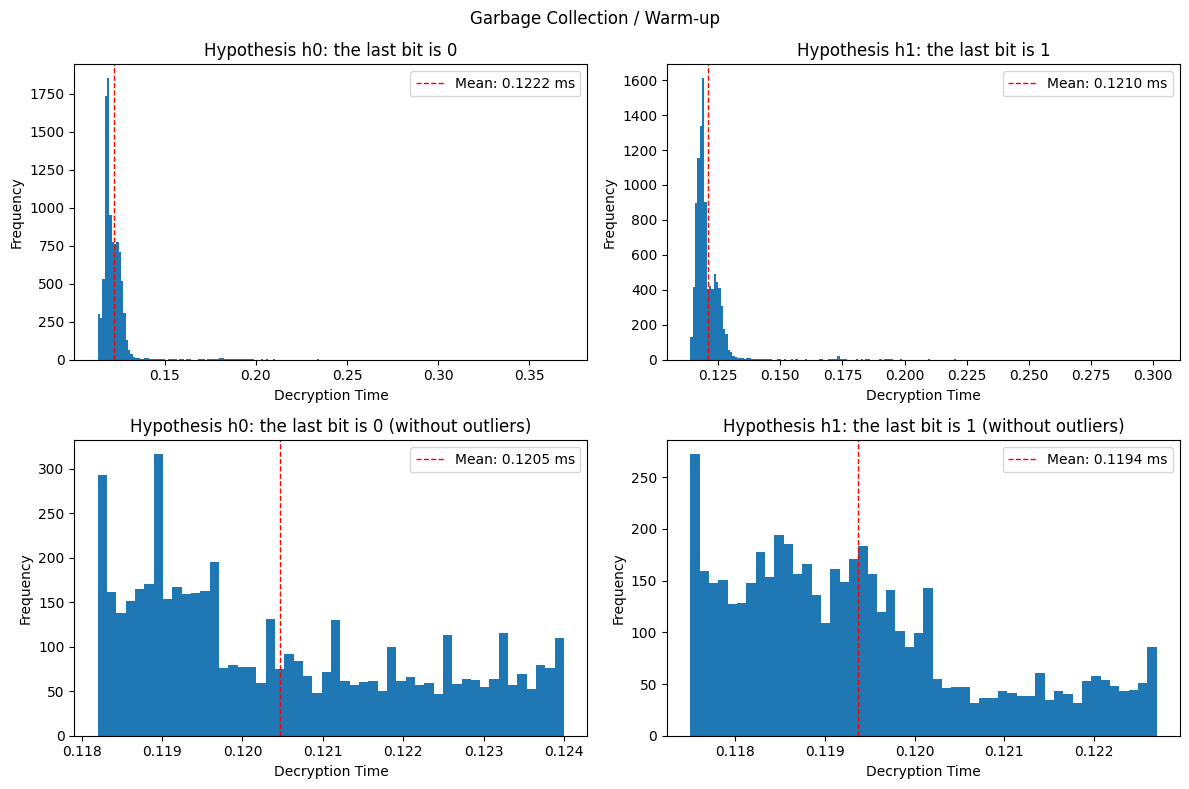

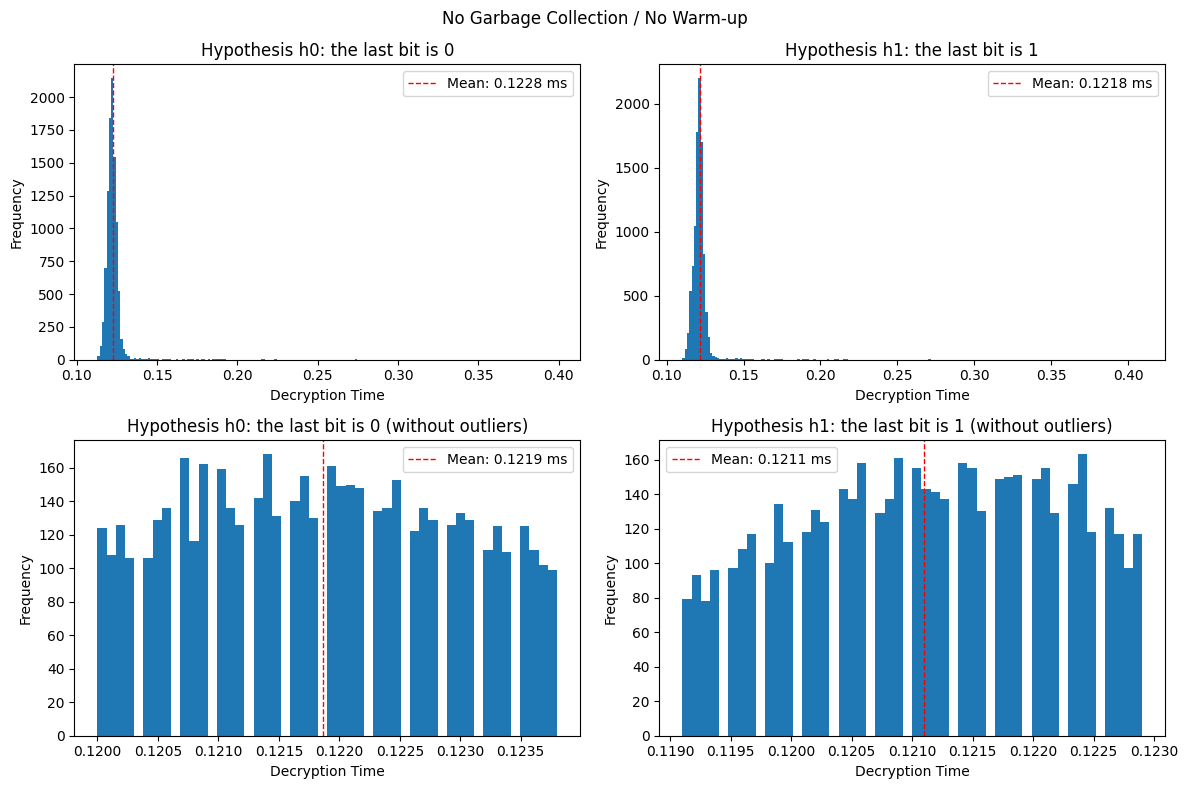

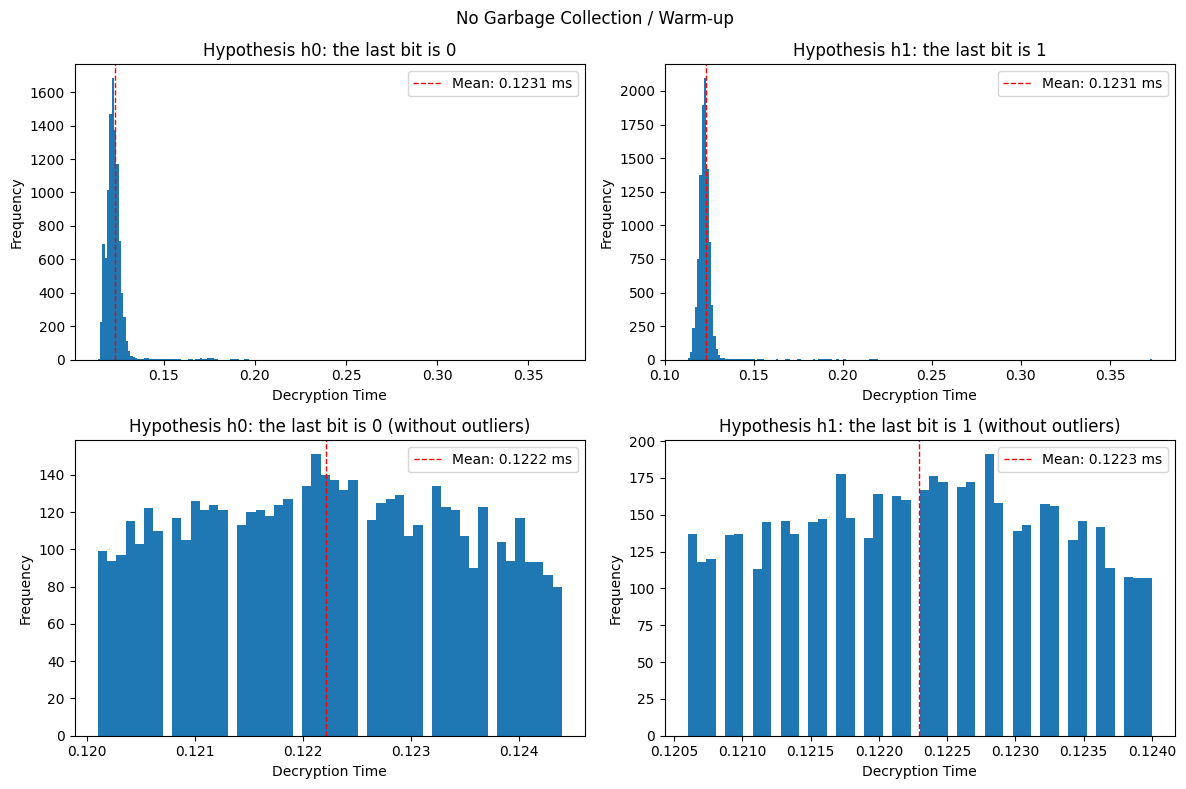

In [23]:
configs = {
    "Garbage Collection / No Warm-up" : dict(disable_gc=False, warmup_reps=0),
    "Garbage Collection / Warm-up"    : dict(disable_gc=False, warmup_reps=200),
    "No Garbage Collection / No Warm-up" : dict(disable_gc=True, warmup_reps=0),
    "No Garbage Collection / Warm-up"    : dict(disable_gc=True, warmup_reps=200),
}

results = {
    label: (
        get_samples_stats(RSA_instance, 0 , **cfg) / 1e6,
        get_samples_stats(RSA_instance, 1 , **cfg) / 1e6,
    )
    for label, cfg in configs.items()
}

for label, (h0, h1) in results.items():
    plot_distributions(h0, h1, title=label)